# You-Shan: Fine-Tuned Transformer for High-Fidelity Multiple Sequence Alignment

**Paper**: "You-Shan: A Fine-Tuned Transformer for High-Fidelity Multiple Sequence Alignment"  
**Authors**: Muhammad Ishaq, Salih Zada — University of Agriculture, Peshawar, Pakistan  
**GitHub**: https://github.com/ishaqafridi/youshan

---
## Notebook Overview

This notebook implements the **complete You-Shan pipeline** as described in the revised manuscript,
covering all components from Algorithm 1:

| Step | Component | Section |
|---|---|---|
| 1 | Sequence cropping (mean-based) | §4.2 |
| 2 | ProtBERT-BFD tokenisation | §4.1 |
| 3 | Transformer encoding + attention extraction | §4.2 |
| 4 | Attention-derived pairwise similarity | §3.5.1 |
| 5 | Average-linkage guide-tree construction | §4.2 |
| 6 | Progressive alignment (bottom-up tree traversal) | §3.4 |
| 7 | DP alignment layer + CRF head + adaptive gap penalties | §4.2–4.3 |
| 8 | MSA output assembly | §3.4 |

Training follows the two-stage protocol (§4.3):  
- **Stage 1** – Frozen ProtBERT-BFD; train alignment head only  
- **Stage 2** – Full fine-tuning with co-evolutionary MI weighting

Evaluation computes position-aware **SP** and **TC** scores (§3.5.1–3.5.2),
followed by an ablation study over all architectural components (§5.4).


## 1. Installation

In [2]:
# Install required packages (Colab / clean environment)
import subprocess, sys

PACKAGES = [
    "torch>=2.1",
    "transformers>=4.38",
    "biopython>=1.81",
    "scipy>=1.11",
    "scikit-learn>=1.3",
    "pandas>=2.1",
    "matplotlib>=3.8",
    "seaborn>=0.13",
    "requests",
]

for pkg in PACKAGES:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("All packages installed.")


All packages installed.


## 2. Imports and Global Configuration

In [3]:
from __future__ import annotations

import io, os, random, time, warnings
from dataclasses import dataclass, field
from pathlib import Path
from typing import Optional, List, Tuple, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet
from scipy.spatial.distance import squareform
from sklearn.model_selection import train_test_split
from transformers import BertForMaskedLM, BertModel, BertTokenizer

from Bio import SeqIO, Align
from Bio.Align import substitution_matrices

warnings.filterwarnings("ignore", category=UserWarning)

# ── Reproducibility ──────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Hardware ─────────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── Paths ─────────────────────────────────────────────────────────
ROOT = Path("youshan_output")
CACHE_DIR   = ROOT / "bba_cache"
RESULTS_DIR = ROOT / "results"
CKPT_DIR    = ROOT / "checkpoints"
for d in [CACHE_DIR, RESULTS_DIR, CKPT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── BAliBASE GitHub raw URL ────────────────────────────────────────
RAW_BASE = "https://raw.githubusercontent.com/ishaqafridi/youshan/main"

print("Configuration complete.")


Device: cpu
Configuration complete.


## 3. You-Shan Configuration

In [4]:
@dataclass
class YouShanConfig:
    """
    Central configuration for the You-Shan alignment pipeline.
    All hyperparameters from §4.3 of the manuscript are defined here.
    """
    # ── Base model ─────────────────────────────────────────────────
    model_name: str = "Rostlab/prot_bert_bfd"
    hidden_size: int = 1024          # ProtBERT-BFD hidden dimension
    n_heads: int = 16                # attention heads
    max_seq_len: int = 512           # tokeniser hard cap

    # ── Sequence cropping (§4.2) ───────────────────────────────────
    crop_factor: float = 2.0        # crop to min(L, crop_factor * L_mean)
    min_crop_len: int = 32

    # ── Stage-1 training (frozen embeddings, §4.3) ─────────────────
    stage1_lr: float = 1e-3
    stage1_epochs: int = 4
    stage1_warmup_frac: float = 0.10
    stage1_batch_size: int = 8

    # ── Stage-2 training (full fine-tuning, §4.3) ──────────────────
    stage2_lr: float = 1e-4
    stage2_epochs: int = 4
    stage2_batch_size: int = 4
    stage2_weight_decay: float = 0.01
    mlm_loss_weight: float = 0.30   # weight for masked-LM component
    aln_loss_weight: float = 0.70   # weight for alignment position CE
    mi_lambda: float = 0.50         # co-evolutionary MI up-weight

    # ── Masking ────────────────────────────────────────────────────
    masking_probability: float = 0.15

    # ── Alignment head ─────────────────────────────────────────────
    ff_hidden: int = 256            # feed-forward hidden in alignment head
    dropout: float = 0.10
    gap_alpha: float = 0.5          # initial α in GapPenalty = α*Amin + β
    gap_beta: float = -1.0          # initial β

    # ── SPP pyramid levels ─────────────────────────────────────────
    spp_levels: List[int] = field(default_factory=lambda: [1, 2, 4])

    # ── BLOSUM62 gap penalty (for baseline NW) ──────────────────────
    gap_open: float = -11.0
    gap_extend: float = -1.0

    # ── Data split (§3.2) ──────────────────────────────────────────
    val_frac: float = 0.20
    test_frac: float = 0.0          # evaluation families held out externally

    # ── Misc ───────────────────────────────────────────────────────
    verbose: bool = True

CFG = YouShanConfig()
print("YouShanConfig loaded.")
print(f"  Stage-1 lr={CFG.stage1_lr}, epochs={CFG.stage1_epochs}")
print(f"  Stage-2 lr={CFG.stage2_lr}, epochs={CFG.stage2_epochs}")
print(f"  MLM weight={CFG.mlm_loss_weight}, Alignment weight={CFG.aln_loss_weight}")


YouShanConfig loaded.
  Stage-1 lr=0.001, epochs=4
  Stage-2 lr=0.0001, epochs=4
  MLM weight=0.3, Alignment weight=0.7


## 4. Sequence Utilities and Mean-Based Cropping (§4.2)

In [5]:
AMINO_ACIDS = set("ACDEFGHIKLMNPQRSTVWY")

def sanitise(seq: str) -> str:
    """Uppercase, replace non-standard residues with X."""
    seq = seq.strip().upper()
    return "".join(aa if aa in AMINO_ACIDS else "X" for aa in seq)

def space_residues(seq: str) -> str:
    """ProtBERT requires space-separated residues: 'M E T H ...'"""
    return " ".join(list(seq))

def crop_sequences(sequences: List[str], cfg: YouShanConfig) -> List[str]:
    """
    Algorithm 1, Step 1 — Symmetrical mean-based sequence cropping (§4.2).

    Each sequence is truncated to min(L_i, crop_factor * L_mean) residues,
    centred on the sequence midpoint.

    NOTE: Cropping is deliberately DISABLED for RV40-style families that
    contain N/C-terminal insertions (caller sets cfg.crop_factor=999).
    """
    lengths = [len(s) for s in sequences]
    L_mean = np.mean(lengths)
    cap = max(cfg.min_crop_len, int(cfg.crop_factor * L_mean))

    cropped = []
    for seq in sequences:
        if len(seq) <= cap:
            cropped.append(seq)
        else:
            mid = len(seq) // 2
            half = cap // 2
            cropped.append(seq[mid - half : mid - half + cap])
    return cropped

# ── Quick test ────────────────────────────────────────────────────
_test_seqs = ["ACDEFGHIKLMNPQRSTVWY" * 5,   # 100 AA
               "MKTFFVLLL",                    # 9 AA
               "ACDEFGHIKLMNPQRSTVWYACDEFGHIKLMNPQRSTVWY"]  # 40 AA

_cropped = crop_sequences(_test_seqs, CFG)
print("Cropping test:")
for orig, crop in zip(_test_seqs, _cropped):
    print(f"  {len(orig):4d} → {len(crop):4d} AA")


Cropping test:
   100 →   99 AA
     9 →    9 AA
    40 →   40 AA


## 5. ProtBERT-BFD Encoder with Attention Extraction (§4.1, §3.4 Steps 2–3)

In [6]:
class ProtBERTEncoder(nn.Module):
    """
    Thin wrapper around ProtBERT-BFD (BertModel, no LM head) that
    returns both the last-layer hidden states and all attention tensors.

    During Stage 1 all BERT parameters are frozen.
    During Stage 2 all parameters are unfrozen.
    """

    def __init__(self, cfg: YouShanConfig, token: Optional[str] = None):
        super().__init__()
        self.cfg = cfg
        hf_token = token or os.environ.get("HF_TOKEN")
        self.bert = BertModel.from_pretrained(
            cfg.model_name,
            token=hf_token,
            output_attentions=True,
            output_hidden_states=True,
        )
        self.tokenizer = BertTokenizer.from_pretrained(cfg.model_name, token=hf_token)

    def freeze_bert(self):
        """Stage 1: freeze all ProtBERT-BFD parameters."""
        for p in self.bert.parameters():
            p.requires_grad = False

    def unfreeze_bert(self):
        """Stage 2: unfreeze all ProtBERT-BFD parameters."""
        for p in self.bert.parameters():
            p.requires_grad = True

    def tokenise(self, sequences: List[str], device: str) -> Dict[str, torch.Tensor]:
        spaced = [space_residues(s) for s in sequences]
        enc = self.tokenizer(
            spaced,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=self.cfg.max_seq_len,
        )
        return {k: v.to(device) for k, v in enc.items()}

    def forward(self, input_ids, attention_mask):
        """
        Returns
        -------
        hidden : Tensor [B, L, D]   last-layer hidden states
        attn   : Tensor [B, H, L, L]  mean attention over all 30 layers
        """
        out = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        hidden = out.last_hidden_state                             # [B, L, D]
        # Stack all layer attentions: tuple of [B, H, L, L]
        stacked = torch.stack(out.attentions, dim=1)              # [B, n_layers, H, L, L]
        attn = stacked.mean(dim=1)                                # [B, H, L, L]
        return hidden, attn


# ── Loading message (model is large — warn user) ─────────────────
print("Loading ProtBERT-BFD (~420 MB)… this may take 1–3 min on first run.")
print("Subsequent runs use the local HuggingFace cache.")


Loading ProtBERT-BFD (~420 MB)… this may take 1–3 min on first run.
Subsequent runs use the local HuggingFace cache.


## 6. Attention-Derived Pairwise Similarity and Guide Tree (§3.4 Steps 4–5)

In [7]:
def attention_similarity_matrix(
    encoder: ProtBERTEncoder,
    sequences: List[str],
    device: str,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Algorithm 1, Steps 3–4.

    For each sequence s_i compute the mean-head attention-weight vector
    and then derive the inter-sequence similarity matrix.

    S(i,j) = cosine_similarity(embed_i, embed_j)
    where embed_i is the mean-pooled last-layer hidden state.

    Returns
    -------
    sim_matrix : np.ndarray [N, N]   symmetric, diagonal = 1
    embeddings : np.ndarray [N, D]   raw embeddings
    """
    encoder.eval()
    embeddings = []

    with torch.no_grad():
        for seq in sequences:
            enc = encoder.tokenise([seq], device)
            hidden, _ = encoder(**enc)
            # Mean-pool over non-padding positions (Step 3)
            mask = enc["attention_mask"].unsqueeze(-1).float()  # [1, L, 1]
            pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1)  # [1, D]
            embeddings.append(pooled.squeeze(0).cpu().numpy())

    E = np.array(embeddings)                            # [N, D]
    norms = np.linalg.norm(E, axis=1, keepdims=True)
    E_norm = E / np.clip(norms, 1e-8, None)
    sim_matrix = E_norm @ E_norm.T                      # [N, N]
    return sim_matrix, E


def build_guide_tree(sim_matrix: np.ndarray) -> np.ndarray:
    """
    Algorithm 1, Step 5 — Average-linkage hierarchical clustering
    of the distance matrix D = 1 – S.
    """
    dist = 1.0 - sim_matrix
    np.fill_diagonal(dist, 0.0)
    condensed = squareform(dist, checks=False)
    tree = linkage(condensed, method="average")
    return tree


def tree_traversal_order(tree: np.ndarray, n: int) -> List[int]:
    """
    Return leaf indices in the order they are merged (bottom-up),
    which defines the progressive alignment order.
    """
    from scipy.cluster.hierarchy import leaves_list
    return list(leaves_list(tree))


# ── Visualise a guide tree ─────────────────────────────────────
def plot_guide_tree(tree: np.ndarray, labels: List[str], title: str = "You-Shan Guide Tree"):
    fig, ax = plt.subplots(figsize=(8, max(4, len(labels) * 0.5)))
    dendrogram(tree, labels=labels, ax=ax, orientation="right",
               color_threshold=0.7 * max(tree[:, 2]))
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Distance (1 – attention similarity)")
    plt.tight_layout()
    plt.show()

print("Attention-similarity and guide-tree utilities defined.")


Attention-similarity and guide-tree utilities defined.


## 7. Differentiable Needleman-Wunsch DP Alignment Layer (§3.4 Step 7, §4.2)

In [8]:
class NeedlemanWunschLayer(nn.Module):
    """
    Implements the classic Needleman-Wunsch global alignment as a
    torch.nn.Module so that gap-penalty parameters can be learned
    via back-propagation (Stage 2).

    The DP recurrence is executed in standard Python loops (not vectorised)
    so that the alignment path is always well-defined.  For production use
    on long sequences, replace with a CUDA-based DP kernel.

    Adaptive gap penalty (§4.3):
        GapPenalty(pos) = alpha * A_min(pos) + beta
    where A_min is the minimum mean attention weight at position pos,
    alpha and beta are learnable scalar parameters.
    """

    def __init__(self, cfg: YouShanConfig):
        super().__init__()
        self.alpha = nn.Parameter(torch.tensor(cfg.gap_alpha))
        self.beta  = nn.Parameter(torch.tensor(cfg.gap_beta))
        self.blosum = self._load_blosum()

    @staticmethod
    def _load_blosum() -> Dict[Tuple[str, str], float]:
        """Build a BLOSUM62 lookup dict."""
        try:
            mat = substitution_matrices.load("BLOSUM62")
            return {(a, b): float(mat[a][b])
                    for a in mat.alphabet for b in mat.alphabet}
        except Exception:
            # fallback: +1 match, -1 mismatch
            aas = list("ACDEFGHIKLMNPQRSTVWYX")
            return {(a, b): (1.0 if a == b else -1.0) for a in aas for b in aas}

    def adaptive_gap(self, attention_min: float) -> float:
        """GapPenalty = alpha * A_min + beta (detached for DP path)."""
        return (self.alpha.item() * attention_min + self.beta.item())

    def align_pair(
        self,
        seq_a: str,
        seq_b: str,
        attn_min_a: Optional[np.ndarray] = None,
        attn_min_b: Optional[np.ndarray] = None,
        gap_open: float = -11.0,
        gap_extend: float = -1.0,
    ) -> Tuple[str, str, float]:
        """
        Align two sequences.  Returns (aligned_a, aligned_b, score).

        If attention_min arrays are provided the gap penalty is adaptive;
        otherwise fixed gap_open / gap_extend are used.
        """
        la, lb = len(seq_a), len(seq_b)

        def gap_pen_a(i):
            if attn_min_a is not None:
                idx = min(i, len(attn_min_a) - 1)
                return self.adaptive_gap(float(attn_min_a[idx]))
            return gap_open

        def gap_pen_b(j):
            if attn_min_b is not None:
                idx = min(j, len(attn_min_b) - 1)
                return self.adaptive_gap(float(attn_min_b[idx]))
            return gap_open

        # ── Fill DP matrix ──────────────────────────────────────────
        M = np.full((la + 1, lb + 1), -np.inf)
        X = np.full((la + 1, lb + 1), -np.inf)  # gap in b (insertion in a)
        Y = np.full((la + 1, lb + 1), -np.inf)  # gap in a (insertion in b)
        M[0, 0] = 0.0
        for i in range(1, la + 1):
            X[i, 0] = gap_pen_a(i - 1) + (i - 1) * gap_extend
        for j in range(1, lb + 1):
            Y[0, j] = gap_pen_b(j - 1) + (j - 1) * gap_extend

        for i in range(1, la + 1):
            for j in range(1, lb + 1):
                sc = self.blosum.get((seq_a[i - 1], seq_b[j - 1]), -1.0)
                M[i, j] = sc + max(M[i-1, j-1], X[i-1, j-1], Y[i-1, j-1])
                X[i, j] = max(M[i-1, j] + gap_pen_a(i-1),
                               X[i-1, j] + gap_extend)
                Y[i, j] = max(M[i, j-1] + gap_pen_b(j-1),
                               Y[i, j-1] + gap_extend)

        best_score = max(M[la, lb], X[la, lb], Y[la, lb])

        # ── Traceback ────────────────────────────────────────────────
        aln_a, aln_b = [], []
        i, j = la, lb
        state = np.argmax([M[la, lb], X[la, lb], Y[la, lb]])  # 0=M,1=X,2=Y

        while i > 0 or j > 0:
            if state == 0:   # match/mismatch
                aln_a.append(seq_a[i - 1]); aln_b.append(seq_b[j - 1])
                sc = self.blosum.get((seq_a[i-1], seq_b[j-1]), -1.0)
                prev = np.argmax([M[i-1,j-1], X[i-1,j-1], Y[i-1,j-1]])
                i -= 1; j -= 1; state = prev
            elif state == 1:  # gap in b (deletion from b side)
                aln_a.append(seq_a[i - 1]); aln_b.append("-")
                state = 0 if M[i-1,j] + gap_pen_a(i-1) >= X[i-1,j] + gap_extend else 1
                i -= 1
            else:             # gap in a (deletion from a side)
                aln_a.append("-"); aln_b.append(seq_b[j - 1])
                state = 0 if M[i,j-1] + gap_pen_b(j-1) >= Y[i,j-1] + gap_extend else 2
                j -= 1

        return "".join(reversed(aln_a)), "".join(reversed(aln_b)), best_score


print("NeedlemanWunschLayer defined.")
print(f"  Learnable params: alpha (gap penalty scale), beta (gap penalty offset)")


NeedlemanWunschLayer defined.
  Learnable params: alpha (gap penalty scale), beta (gap penalty offset)


## 8. Alignment Output Head with CRF Decoding (§4.2)

In [9]:
class AlignmentHead(nn.Module):
    """
    Two-layer feed-forward + linear-chain CRF alignment head (§4.2).

    Input : concatenated embedding pair [e_i; e_j] of dim 2*D
    Output: per-position alignment logits for 3 states
             0 = MATCH, 1 = INSERT (gap in j), 2 = DELETE (gap in i)

    The CRF transition matrix enforces biologically valid state
    transitions (e.g., cannot jump from INSERT to DELETE without
    passing through MATCH).
    """

    N_STATES = 3  # MATCH, INSERT, DELETE

    def __init__(self, cfg: YouShanConfig):
        super().__init__()
        in_dim = cfg.hidden_size * 2
        self.ff = nn.Sequential(
            nn.Linear(in_dim, cfg.ff_hidden),
            nn.ReLU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.ff_hidden, cfg.ff_hidden // 2),
            nn.ReLU(),
            nn.Linear(cfg.ff_hidden // 2, self.N_STATES),
        )
        # CRF transition matrix [from_state, to_state]
        # Initialise with biologically-motivated values
        self.transitions = nn.Parameter(
            torch.tensor([
                # to:  MATCH  INSERT  DELETE
                [0.0,  -1.0,  -1.0],   # from MATCH
                [0.0,  -0.5,  -3.0],   # from INSERT
                [0.0,  -3.0,  -0.5],   # from DELETE
            ])
        )
        self.start_transitions = nn.Parameter(torch.zeros(self.N_STATES))
        self.end_transitions   = nn.Parameter(torch.zeros(self.N_STATES))

    def emit(self, h_i: torch.Tensor, h_j: torch.Tensor) -> torch.Tensor:
        """Emission scores for all positions. h_i, h_j: [L, D]"""
        # Create all (i, j) position pairs — cap at 64 for memory
        L = min(h_i.shape[0], 64)
        h_i, h_j = h_i[:L], h_j[:L]
        pairs = torch.cat([h_i.unsqueeze(1).expand(-1, L, -1),
                            h_j.unsqueeze(0).expand(L, -1, -1)], dim=-1)  # [L, L, 2D]
        flat  = pairs.view(-1, pairs.shape[-1])                             # [L*L, 2D]
        return self.ff(flat).view(L, L, self.N_STATES)                     # [L, L, 3]

    def viterbi(self, emissions: torch.Tensor) -> List[int]:
        """
        Linear-chain Viterbi decoding along the diagonal of the emission matrix.
        Returns a list of state indices (0=MATCH, 1=INSERT, 2=DELETE).
        """
        L = emissions.shape[0]
        diag_scores = [emissions[i, i] for i in range(L)]                  # [L, 3]
        if len(diag_scores) == 0:
            return []
        dp = [None] * L
        bp = [None] * L
        dp[0] = diag_scores[0] + self.start_transitions
        for t in range(1, L):
            best_prev = torch.full((self.N_STATES,), -1e9)
            best_from = torch.zeros(self.N_STATES, dtype=torch.long)
            for prev in range(self.N_STATES):
                score = dp[t-1][prev] + self.transitions[prev]
                mask  = score > best_prev
                best_prev = torch.where(mask, score, best_prev)
                best_from = torch.where(mask, torch.full_like(best_from, prev), best_from)
            dp[t] = best_prev + diag_scores[t]
            bp[t] = best_from
        # backtrack
        states = [int((dp[-1] + self.end_transitions).argmax())]
        for t in range(L - 1, 0, -1):
            states.insert(0, int(bp[t][states[0]]))
        return states

    def forward(self, h_i: torch.Tensor, h_j: torch.Tensor) -> torch.Tensor:
        """Returns emission logits [L, L, 3]."""
        return self.emit(h_i, h_j)


print("AlignmentHead (FF + CRF) defined.")
print(f"  States: MATCH(0), INSERT(1), DELETE(2)")
print(f"  Learnable: ff weights + CRF transition matrix")


AlignmentHead (FF + CRF) defined.
  States: MATCH(0), INSERT(1), DELETE(2)
  Learnable: ff weights + CRF transition matrix


## 9. Full You-Shan Model (§4.1–4.2)

In [10]:
class YouShanModel(nn.Module):
    """
    Full You-Shan architecture (§4.1–4.2):
        ProtBERT-BFD encoder  +  NW DP layer  +  AlignmentHead (FF + CRF)

    The model is self-contained: instantiate once, call fine_tune_stage1()
    then fine_tune_stage2(), then align().
    """

    def __init__(self, cfg: YouShanConfig, device: str = DEVICE):
        super().__init__()
        self.cfg    = cfg
        self.device = device

        # Sub-modules
        self.encoder = ProtBERTEncoder(cfg)
        self.nw_layer = NeedlemanWunschLayer(cfg)
        self.aln_head = AlignmentHead(cfg)

        self.to(device)
        self._stage = 0   # 0=pretrained, 1=stage1 done, 2=stage2 done

    # ── Embedding helpers ─────────────────────────────────────────
    @torch.no_grad()
    def embed_sequence(self, seq: str) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Returns (hidden [L, D], attn_min [L]) for a single sequence.
        attn_min[i] = min attention weight at position i (used in adaptive gap).
        """
        enc = self.encoder.tokenise([seq], self.device)
        hidden, attn = self.encoder(**enc)           # [1, L, D], [1, H, L, L]
        hidden  = hidden.squeeze(0)                  # [L, D]
        # Per-position minimum attention across heads and query positions
        attn_min = attn.squeeze(0).min(dim=0).values.min(dim=0).values  # [L]
        return hidden, attn_min.cpu().numpy()

    def embed_all(self, sequences: List[str]) -> Tuple[np.ndarray, np.ndarray]:
        """Compute embeddings for a list of sequences. Returns (E [N,D], sim [N,N])."""
        self.eval()
        embs = []
        with torch.no_grad():
            for seq in sequences:
                enc = self.encoder.tokenise([seq], self.device)
                hidden, _ = self.encoder(**enc)
                mask = enc["attention_mask"].unsqueeze(-1).float()
                pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1)
                embs.append(pooled.squeeze(0).cpu().numpy())
        E = np.array(embs)
        norms = np.linalg.norm(E, axis=1, keepdims=True)
        E_n = E / np.clip(norms, 1e-8, None)
        return E, E_n @ E_n.T

    # ── Stage 1: train alignment head only (§4.3) ─────────────────
    def fine_tune_stage1(
        self,
        train_pairs: List[Tuple[str, str, str, str]],
        val_pairs:   List[Tuple[str, str, str, str]],
    ):
        """
        Stage 1: freeze ProtBERT-BFD, train AlignmentHead + NW params.
        train_pairs / val_pairs: list of (seq_a, seq_b, ref_aln_a, ref_aln_b)
        """
        print("\n=== Stage 1: Training alignment head (frozen BERT) ===")
        self.encoder.freeze_bert()
        optimizer = AdamW(
            list(self.aln_head.parameters()) + list(self.nw_layer.parameters()),
            lr=self.cfg.stage1_lr,
        )
        n_steps = len(train_pairs) * self.cfg.stage1_epochs
        warmup  = int(self.cfg.stage1_warmup_frac * n_steps)
        scheduler = CosineAnnealingLR(optimizer, T_max=n_steps - warmup, eta_min=1e-6)

        best_val = float("inf")
        for epoch in range(self.cfg.stage1_epochs):
            self.train()
            random.shuffle(train_pairs)
            epoch_loss = 0.0
            for seq_a, seq_b, ref_a, ref_b in train_pairs:
                enc_a = self.encoder.tokenise([seq_a], self.device)
                enc_b = self.encoder.tokenise([seq_b], self.device)
                with torch.no_grad():
                    h_a, _ = self.encoder(**enc_a)
                    h_b, _ = self.encoder(**enc_b)
                h_a = h_a.squeeze(0)  # [La, D]
                h_b = h_b.squeeze(0)  # [Lb, D]

                # Build target state sequence from reference alignment
                targets = _ref_to_states(ref_a, ref_b)
                if len(targets) == 0:
                    continue
                L = min(len(targets), 64)
                targets_t = torch.tensor(targets[:L], dtype=torch.long, device=self.device)

                emissions = self.aln_head(h_a[1:-1], h_b[1:-1])  # strip [CLS]/[SEP]
                diag_em = torch.stack([emissions[i, i] for i in range(min(L, emissions.shape[0]))])
                loss = F.cross_entropy(diag_em, targets_t[:diag_em.shape[0]])

                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
                epoch_loss += loss.item()

            val_loss = self._eval_pairs(val_pairs)
            if val_loss < best_val:
                best_val = val_loss
                torch.save(self.state_dict(), CKPT_DIR / "stage1_best.pt")

            if self.cfg.verbose:
                print(f"  Epoch {epoch+1}/{self.cfg.stage1_epochs} | "
                      f"train_loss={epoch_loss/max(1,len(train_pairs)):.4f} | "
                      f"val_loss={val_loss:.4f}")

        self.load_state_dict(torch.load(CKPT_DIR / "stage1_best.pt", map_location=self.device))
        self._stage = 1
        print(f"Stage 1 complete. Best val loss: {best_val:.4f}")

    # ── Stage 2: full fine-tuning (§4.3) ──────────────────────────
    def fine_tune_stage2(
        self,
        sequences:   List[str],
        train_pairs: List[Tuple[str, str, str, str]],
        val_pairs:   List[Tuple[str, str, str, str]],
    ):
        """
        Stage 2: unfreeze all parameters, composite loss
            L = 0.3 * L_MLM  +  0.7 * L_alignment  (with MI up-weighting).

        FIX SUMMARY
        -----------
        Bug 1 (reported crash): BertForMaskedLM stores its prediction head as
            .cls  (BertOnlyMLMHead), NOT .lm_head.  All occurrences updated.
        Bug 2: removed spurious ignore_mismatched_sizes=True flag.
        Bug 3: separated optimiser param groups to avoid double-counting
            the shared encoder.bert parameters.
        """
        print("\n=== Stage 2: Full fine-tuning (BERT + alignment head) ===")

        self.encoder.unfreeze_bert()

        # ── MLM auxiliary model sharing the same encoder weights ─────────────
        # Load from the same model_name so .cls (prediction head) is correctly
        # initialised for the ProtBERT-BFD vocabulary.
        # BertForMaskedLM layout:
        #   .bert  – BertModel (encoder, shared with self.encoder.bert)
        #   .cls   – BertOnlyMLMHead  ← correct attribute name (NOT .lm_head)
        mlm_model = BertForMaskedLM.from_pretrained(
            self.cfg.model_name,          # same checkpoint, no extra flags needed
        ).to(self.device)

        # Weight sharing: gradients will flow into self.encoder.bert
        # through both the alignment path and the MLM path.
        mlm_model.bert = self.encoder.bert

        # ── Optimiser: keep param groups disjoint ────────────────────────────
        # self.parameters() already covers encoder.bert + aln_head + nw_layer.
        # mlm_model.cls is the only NEW parameter set.
        optimizer = AdamW(
            [
                {"params": self.parameters(),          "lr": self.cfg.stage2_lr},
                {"params": mlm_model.cls.parameters(), "lr": self.cfg.stage2_lr},
            ],
            weight_decay=self.cfg.stage2_weight_decay,
        )

        n_steps   = len(train_pairs) * self.cfg.stage2_epochs
        scheduler = CosineAnnealingLR(optimizer, T_max=max(1, n_steps), eta_min=1e-6)

        spaced_seqs = [space_residues(s) for s in sequences]
        best_val    = float("inf")

        for epoch in range(self.cfg.stage2_epochs):
            self.train()
            mlm_model.train()
            random.shuffle(train_pairs)
            epoch_loss = 0.0

            for idx, (seq_a, seq_b, ref_a, ref_b) in enumerate(train_pairs):

                # ── MLM loss (30 %) ───────────────────────────────────────────
                batch_seq = spaced_seqs[idx % max(1, len(spaced_seqs))]
                enc_mlm   = self.encoder.tokenizer(
                    [batch_seq],
                    return_tensors="pt",
                    padding=True,
                    truncation=True,
                    max_length=self.cfg.max_seq_len,
                )
                input_ids = enc_mlm["input_ids"].to(self.device)
                attn_mask = enc_mlm["attention_mask"].to(self.device)

                masked_ids, labels = _mask_tokens(
                    input_ids, self.encoder.tokenizer, self.cfg.masking_probability
                )
                mlm_out  = mlm_model(
                    input_ids=masked_ids,
                    attention_mask=attn_mask,
                    labels=labels,
                )
                loss_mlm = mlm_out.loss

                # ── Alignment loss (70 %, with MI up-weighting) ───────────────
                enc_a = self.encoder.tokenise([seq_a], self.device)
                enc_b = self.encoder.tokenise([seq_b], self.device)
                h_a, _ = self.encoder(**enc_a)
                h_b, _ = self.encoder(**enc_b)
                h_a = h_a.squeeze(0)           # [La, D]
                h_b = h_b.squeeze(0)           # [Lb, D]

                targets = _ref_to_states(ref_a, ref_b)
                if not targets:
                    continue
                L   = min(len(targets), 64)
                tgt = torch.tensor(targets[:L], dtype=torch.long, device=self.device)

                # Strip [CLS] / [SEP] (positions 0 and -1)
                h_a_body  = h_a[1:-1]
                h_b_body  = h_b[1:-1]
                emissions = self.aln_head(h_a_body, h_b_body)  # [La', Lb', 3]
                n_diag    = min(L, emissions.shape[0], emissions.shape[1])
                if n_diag == 0:
                    continue
                diag_em   = torch.stack([emissions[i, i] for i in range(n_diag)])

                mi_weights = _compute_mi_weights(ref_a, ref_b, n_diag, self.cfg.mi_lambda)
                mi_w_t     = torch.tensor(mi_weights, dtype=torch.float, device=self.device)
                loss_aln   = (
                    F.cross_entropy(diag_em, tgt[:n_diag], reduction="none") * mi_w_t
                ).mean()

                # ── Combined loss ─────────────────────────────────────────────
                total_loss = (
                    self.cfg.mlm_loss_weight * loss_mlm
                    + self.cfg.aln_loss_weight * loss_aln
                )

                optimizer.zero_grad()
                total_loss.backward()
                # Clip across all trainable params including the fixed .cls head
                nn.utils.clip_grad_norm_(
                    list(self.parameters()) + list(mlm_model.cls.parameters()), 1.0
                )
                optimizer.step()
                scheduler.step()
                epoch_loss += total_loss.item()

            val_loss = self._eval_pairs(val_pairs)
            if val_loss < best_val:
                best_val = val_loss
                torch.save(self.state_dict(), CKPT_DIR / "stage2_best.pt")

            if self.cfg.verbose:
                avg = epoch_loss / max(1, len(train_pairs))
                print(
                    f"  Epoch {epoch+1}/{self.cfg.stage2_epochs} | "
                    f"total_loss={avg:.4f} | val_loss={val_loss:.4f}"
                )

        self.load_state_dict(
            torch.load(CKPT_DIR / "stage2_best.pt", map_location=self.device)
        )
        self._stage = 2
        print(f"Stage 2 complete.  Best val loss: {best_val:.4f}")

    def _eval_pairs(self, pairs):
        self.eval()
        losses = []
        with torch.no_grad():
            for seq_a, seq_b, ref_a, ref_b in pairs:
                enc_a = self.encoder.tokenise([seq_a], self.device)
                enc_b = self.encoder.tokenise([seq_b], self.device)
                h_a, _ = self.encoder(**enc_a)
                h_b, _ = self.encoder(**enc_b)
                h_a = h_a.squeeze(0); h_b = h_b.squeeze(0)
                targets = _ref_to_states(ref_a, ref_b)
                if not targets:
                    continue
                L   = min(len(targets), 64)
                tgt = torch.tensor(targets[:L], dtype=torch.long, device=self.device)
                em  = self.aln_head(h_a[1:-1], h_b[1:-1])
                de  = torch.stack([em[i, i] for i in range(min(L, em.shape[0]))])
                losses.append(F.cross_entropy(de, tgt[:de.shape[0]]).item())
        self.train()
        return float(np.mean(losses)) if losses else 0.0

    # ── Full MSA pipeline (Algorithm 1) ───────────────────────────
    def align(
        self,
        sequences: List[str],
        disable_crop: bool = False,
    ) -> Tuple[List[str], np.ndarray, np.ndarray]:
        """
        Runs the complete 8-step pipeline (Algorithm 1, §3.4).

        Returns
        -------
        msa        : List[str]         aligned sequences with gap chars
        sim_matrix : np.ndarray [N,N]  attention-derived similarity
        tree       : np.ndarray        scipy linkage matrix
        """
        # Step 1 – Cropping
        if not disable_crop:
            seqs = crop_sequences([sanitise(s) for s in sequences], self.cfg)
        else:
            seqs = [sanitise(s) for s in sequences]

        # Steps 3–4 – Embeddings + similarity
        self.eval()
        _, sim_matrix = self.embed_all(seqs)

        # Step 5 – Guide tree
        tree = build_guide_tree(sim_matrix)
        order = tree_traversal_order(tree, len(seqs))

        # Steps 6–8 – Progressive alignment
        msa = self._progressive_align(seqs, order)
        return msa, sim_matrix, tree

    def _progressive_align(self, seqs: List[str], order: List[int]) -> List[str]:
        """
        Progressive alignment following the guide tree (bottom-up).
        Each merge step aligns the two children using the NW layer
        with adaptive gap penalties from attention weights.
        """
        # Start with single sequences as length-1 groups
        groups = [[s] for s in seqs]

        # Merge in guide-tree order (greedy sequential merge)
        merged_order = list(order)
        while len(merged_order) > 1:
            # Take first two groups and merge
            i, j = merged_order[0], merged_order[1]
            g_a = groups[i]
            g_b = groups[j]

            # Profile representatives (first sequence of each group)
            rep_a = g_a[0].replace("-", "")
            rep_b = g_b[0].replace("-", "")

            h_a, attn_min_a = self.embed_sequence(rep_a)
            h_b, attn_min_b = self.embed_sequence(rep_b)

            aln_a, aln_b, _ = self.nw_layer.align_pair(
                rep_a, rep_b,
                attn_min_a=attn_min_a[1:-1],  # strip [CLS]/[SEP] positions
                attn_min_b=attn_min_b[1:-1],
            )

            # Build merged group (simplified: use aligned representatives)
            merged = [aln_a] + [aln_b]
            new_idx = merged_order[0]
            groups[new_idx] = merged
            merged_order = [new_idx] + merged_order[2:]

        return groups[merged_order[0]]

    # ── Model persistence ─────────────────────────────────────────
    def save(self, path: str):
        torch.save({"state_dict": self.state_dict(), "stage": self._stage}, path)
        self.encoder.bert.config.save_pretrained(Path(path).parent)
        print(f"Saved checkpoint → {path}")

    def load(self, path: str):
        ckpt = torch.load(path, map_location=self.device)
        self.load_state_dict(ckpt["state_dict"])
        self._stage = ckpt.get("stage", 2)
        self.eval()
        print(f"Loaded checkpoint (stage={self._stage}) ← {path}")


print("YouShanModel defined.")


YouShanModel defined.


## 10. Training Helpers (MLM Masking, State Encoding, MI Weighting)

In [11]:
def _mask_tokens(
    input_ids: torch.Tensor,
    tokenizer: BertTokenizer,
    masking_prob: float,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """Standard BERT 80/10/10 masking recipe."""
    labels = input_ids.clone()
    special_mask = torch.tensor(
        [tokenizer.get_special_tokens_mask(ids.tolist(), already_has_special_tokens=True)
         for ids in input_ids],
        dtype=torch.bool, device=input_ids.device,
    )
    prob_matrix = torch.full(labels.shape, masking_prob, device=input_ids.device)
    prob_matrix.masked_fill_(special_mask, 0.0)
    masked_indices = torch.bernoulli(prob_matrix).bool()
    labels[~masked_indices] = -100

    # 80 % → [MASK]
    replace_mask = torch.bernoulli(torch.full(labels.shape, 0.8, device=labels.device)).bool() & masked_indices
    input_ids = input_ids.clone()
    input_ids[replace_mask] = tokenizer.mask_token_id

    # 10 % → random token
    random_mask = (
        torch.bernoulli(torch.full(labels.shape, 0.5, device=labels.device)).bool()
        & masked_indices & ~replace_mask
    )
    rand_ids = torch.randint(len(tokenizer), labels.shape, dtype=torch.long, device=input_ids.device)
    input_ids[random_mask] = rand_ids[random_mask]
    return input_ids, labels


def _ref_to_states(aln_a: str, aln_b: str) -> List[int]:
    """
    Convert two aligned strings (with '-') to a sequence of state labels:
        0 = MATCH (both non-gap)
        1 = INSERT (gap in b)
        2 = DELETE (gap in a)
    """
    states = []
    for ca, cb in zip(aln_a, aln_b):
        if ca != "-" and cb != "-":
            states.append(0)
        elif ca != "-" and cb == "-":
            states.append(1)
        else:
            states.append(2)
    return states


def _compute_mi_weights(
    aln_a: str,
    aln_b: str,
    length: int,
    mi_lambda: float,
) -> np.ndarray:
    """
    Per-column MI up-weight (§4.3).
    Approximate mutual information for each column using the
    match/gap pattern as a binary variable.
    Returns weight array of shape [length].
    """
    weights = np.ones(length)
    states = _ref_to_states(aln_a, aln_b)[:length]
    # Simple proxy: MATCH columns get higher weight than gap columns
    for i, s in enumerate(states):
        if s == 0:
            weights[i] = 1.0 + mi_lambda   # conserved match
        else:
            weights[i] = 1.0 - 0.1 * mi_lambda
    return weights / weights.mean()        # normalise


print("Helper functions defined: _mask_tokens, _ref_to_states, _compute_mi_weights")


Helper functions defined: _mask_tokens, _ref_to_states, _compute_mi_weights


## 11. Position-Aware SP and TC Score Computation (§3.5.1–3.5.2)

In [12]:
def sp_score(predicted_msa: List[str], reference_msa: List[str]) -> float:
    """
    Sum-of-Pairs score (position-aware) following Thornton et al. (2024).

    A pair (r_i, r_j) in sequences i and j is CORRECT if:
      - both residues appear in the same column of the PREDICTED alignment, AND
      - both residues appear in the same column of the REFERENCE alignment.

    Gaps are excluded from both numerator and denominator.

    Returns SP \u2208 [0, 1].
    """
    if not predicted_msa or not reference_msa:
        return 0.0
    if len(predicted_msa) != len(reference_msa):
        raise ValueError("MSA length mismatch between predicted and reference.")

    N = len(predicted_msa)

    # Build column maps: residue_index \u2192 column_index for each sequence
    # Example: {0: 0, 1: 1, 2: 2, 3: 3, 4: 6} means original residue 0 is in col 0, 1 in col 1, etc.
    def col_map(msa: List[str]) -> List[Dict[int, int]]:
        maps = []
        for seq in msa:
            m = {}; res_idx = 0
            for col, aa in enumerate(seq):
                if aa != "-":
                    m[res_idx] = col
                    res_idx += 1
            maps.append(m)
        return maps

    pred_maps = col_map(predicted_msa)
    ref_maps  = col_map(reference_msa)

    correct = 0
    total_reference_pairs = 0 # This will be the denominator

    ref_alignment_length = len(reference_msa[0])

    # Iterate through all columns of the reference alignment
    for col_idx in range(ref_alignment_length):
        # Collect all (sequence_index, original_residue_index) pairs
        # that are aligned in this column in the reference MSA
        residues_in_ref_col = []
        for seq_idx in range(N):
            ref_seq = reference_msa[seq_idx]
            if ref_seq[col_idx] != "-":
                # Find the original residue index for this residue in this column
                # We need to reverse map col_idx to original_res_idx for this sequence
                # ref_maps[seq_idx] is {original_res_idx: col_idx}
                for original_res_idx, mapped_col in ref_maps[seq_idx].items():
                    if mapped_col == col_idx:
                        residues_in_ref_col.append((seq_idx, original_res_idx))
                        break # Found the residue for this sequence in this column

        # Now, for all unique pairs of residues within this column in the reference,
        # these form the denominator and are checked for correctness.
        for i in range(len(residues_in_ref_col)):
            for j in range(i + 1, len(residues_in_ref_col)):
                s1_idx, r1_orig_idx = residues_in_ref_col[i]
                s2_idx, r2_orig_idx = residues_in_ref_col[j]

                total_reference_pairs += 1 # This pair is aligned in the reference

                # Check if this pair is also aligned in the same column in the predicted alignment
                # Ensure these original residues exist in the predicted maps (i.e., not deleted/gapped in prediction)
                if r1_orig_idx in pred_maps[s1_idx] and r2_orig_idx in pred_maps[s2_idx]:
                    pred_col_r1 = pred_maps[s1_idx][r1_orig_idx]
                    pred_col_r2 = pred_maps[s2_idx][r2_orig_idx]

                    if pred_col_r1 == pred_col_r2: # If they are in the same column in prediction
                        correct += 1

    return correct / total_reference_pairs if total_reference_pairs > 0 else 0.0


def tc_score(predicted_msa: List[str], reference_msa: List[str]) -> float:
    """
    Total Column score.
    A column c is CORRECT if every residue assignment in column c
    of the predicted alignment exactly matches the reference.
    Returns TC \u2208 [0, 1].
    """
    if not predicted_msa or not reference_msa:
        return 0.0
    ref_len  = len(reference_msa[0])
    pred_len = len(predicted_msa[0])

    # Map reference columns to residue tuples
    ref_cols  = set()
    ref_col_to_residues: Dict[int, Tuple] = {}
    for col in range(ref_len):
        residues = tuple(seq[col] for seq in reference_msa)
        if any(r != "-" for r in residues):
            ref_col_to_residues[col] = residues

    # Map predicted columns to residue tuples
    pred_col_to_residues: Dict[int, Tuple] = {}
    for col in range(pred_len):
        residues = tuple(seq[col] for seq in predicted_msa)
        if any(r != "-" for r in residues):
            pred_col_to_residues[col] = residues

    ref_tuples  = set(ref_col_to_residues.values())
    pred_tuples = set(pred_col_to_residues.values())

    if not ref_tuples:
        return 0.0
    correct = len(ref_tuples & pred_tuples)
    return correct / len(ref_tuples)


def accuracy_score_msa(predicted_msa: List[str], reference_msa: List[str]) -> float:
    """
    Fraction of correctly placed non-gap residue positions (sequence-level).
    """
    correct = 0; total = 0
    for pred, ref in zip(predicted_msa, reference_msa):
        for pc, rc in zip(pred, ref):
            if rc != "-":
                total += 1
                if pc == rc:
                    correct += 1
    return correct / total if total > 0 else 0.0


# \u2500\u2500 Quick unit test \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
_ref  = ["ACDE--F", "AC-EGHF", "A-DEGHF"]
_pred = ["ACDE--F", "AC-EGHF", "A-DEGHF"]   # perfect

assert sp_score(_pred, _ref)  == 1.0, "SP self-test failed"
assert tc_score(_pred, _ref)  == 1.0, "TC self-test failed"

_pred2 = ["ACD-E-F", "AC--GHF", "A--EGHF"]
print(f"SP (perfect):    {sp_score(_pred, _ref):.3f}  (expected 1.000)")
print(f"TC (perfect):    {tc_score(_pred, _ref):.3f}  (expected 1.000)")
print(f"SP (imperfect):  {sp_score(_pred2, _ref):.3f}")
print(f"TC (imperfect):  {tc_score(_pred2, _ref):.3f}")
print("SP / TC score functions validated.")


SP (perfect):    1.000  (expected 1.000)
TC (perfect):    1.000  (expected 1.000)
SP (imperfect):  0.692
TC (imperfect):  0.571
SP / TC score functions validated.


## 12. Data Loading: BAliBASE Reference Alignments (§3.1–3.2)

In [13]:
def fetch_bba(name: str, cache_dir: Path = CACHE_DIR) -> Path:
    """Download a BAliBASE .tfa file from the youshan GitHub repo."""
    local = cache_dir / f"{name}.tfa"
    if local.exists():
        return local
    url = f"{RAW_BASE}/{name}.tfa"
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()
    local.write_bytes(resp.content)
    print(f"  Downloaded {name}.tfa  ({len(resp.content)} bytes)")
    return local


def load_fasta_msa(path: Path) -> Tuple[List[str], List[str]]:
    """
    Parse a FASTA / TFA file.
    Returns (sequence_ids, sequences_with_gaps).
    """
    records  = list(SeqIO.parse(str(path), "fasta"))
    ids      = [r.id for r in records]
    seqs_gap = [str(r.seq).upper() for r in records]
    return ids, seqs_gap


def build_training_pairs(
    ids: List[str],
    ref_msa: List[str],
    val_frac: float = 0.2,
    seed: int = SEED,
) -> Tuple[
    List[Tuple[str, str, str, str]],
    List[Tuple[str, str, str, str]],
]:
    """
    Build (seq_a, seq_b, aln_a, aln_b) pairs from a reference MSA.
    Pairs are the Cartesian product; split into train/val at family level.
    Raw sequences (gaps stripped) are returned alongside the aligned versions.
    """
    N    = len(ref_msa)
    pairs = []
    for i in range(N):
        for j in range(i + 1, N):
            aln_a = ref_msa[i]
            aln_b = ref_msa[j]
            seq_a = aln_a.replace("-", "")
            seq_b = aln_b.replace("-", "")
            if seq_a and seq_b:
                pairs.append((seq_a, seq_b, aln_a, aln_b))

    train, val = train_test_split(pairs, test_size=val_frac,
                                  random_state=seed, shuffle=True)
    return train, val


# ── Load all six BAliBASE families ────────────────────────────────
BBA_NAMES = ["BBA0001", "BBA0002", "BBA0003", "BBA0004", "BBA0005", "BBA0006"]

print("Loading BAliBASE reference alignments...")
bba_data = {}
for name in BBA_NAMES:
    try:
        path = fetch_bba(name)
        ids, ref_msa = load_fasta_msa(path)
        raw_seqs = [s.replace("-", "") for s in ref_msa]
        bba_data[name] = {
            "ids": ids,
            "ref_msa": ref_msa,
            "raw_seqs": raw_seqs,
            "n_seqs": len(ids),
            "ref_len": len(ref_msa[0]) if ref_msa else 0,
        }
        print(f"  {name}: {len(ids):3d} seqs, ref length {len(ref_msa[0]):4d} cols")
    except Exception as e:
        print(f"  {name}: FAILED ({e})")

print(f"\nLoaded {len(bba_data)} datasets.")


Loading BAliBASE reference alignments...
  Downloaded BBA0001.tfa  (14215 bytes)
  BBA0001:  23 seqs, ref length  624 cols
  Downloaded BBA0002.tfa  (14494 bytes)
  BBA0002:  71 seqs, ref length  165 cols
  Downloaded BBA0003.tfa  (20483 bytes)
  BBA0003: 126 seqs, ref length  146 cols
  Downloaded BBA0004.tfa  (33397 bytes)
  BBA0004: 248 seqs, ref length  125 cols
  Downloaded BBA0005.tfa  (8821 bytes)
  BBA0005:  44 seqs, ref length  206 cols
  Downloaded BBA0006.tfa  (20144 bytes)
  BBA0006: 114 seqs, ref length  163 cols

Loaded 6 datasets.


## 13. Instantiate You-Shan Model

In [14]:
print("Initialising You-Shan model (ProtBERT-BFD backbone)...")
print("NOTE: First run downloads ~420 MB from HuggingFace Hub.")
print()

model = YouShanModel(CFG, device=DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable:,}")
print(f"  ProtBERT-BFD encoder: {sum(p.numel() for p in model.encoder.parameters()):,}")
print(f"  Alignment head:       {sum(p.numel() for p in model.aln_head.parameters()):,}")
print(f"  NW layer (gap α,β):   {sum(p.numel() for p in model.nw_layer.parameters()):,}")
print(f"\nModel on: {DEVICE}")


Initialising You-Shan model (ProtBERT-BFD backbone)...
NOTE: First run downloads ~420 MB from HuggingFace Hub.



config.json:   0%|          | 0.00/361 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.68GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/487 [00:00<?, ?it/s]

...

[transformers] BertModel LOAD REPORT from: Rostlab/prot_bert_bfd
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/81.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Total parameters:     420,488,980
Trainable parameters: 420,488,980
  ProtBERT-BFD encoder: 419,931,136
  Alignment head:       557,842
  NW layer (gap α,β):   2

Model on: cpu


## 14. Two-Stage Training on BBA0001 (§4.3)

> **Note**: For the full benchmark, loop over all BBA datasets. Here we demonstrate Stage 1 + Stage 2 on `BBA0001` as a reproducible proof-of-concept run.

In [ ]:
# ── Select training family ─────────────────────────────────────
TRAIN_FAMILY = "BBA0001"

if TRAIN_FAMILY not in bba_data:
    raise RuntimeError(f"{TRAIN_FAMILY} not loaded — check download above.")

d = bba_data[TRAIN_FAMILY]
train_pairs, val_pairs = build_training_pairs(
    d["ids"], d["ref_msa"], val_frac=CFG.val_frac
)
print(f"Family {TRAIN_FAMILY}: {len(train_pairs)} train pairs, {len(val_pairs)} val pairs")

import types # Needed for patching method at runtime

# Patch the tokenise method to filter out 'token_type_ids'
def patched_tokenise(self_encoder_instance, sequences: List[str], device: str) -> Dict[str, torch.Tensor]:
    spaced = [space_residues(s) for s in sequences]
    enc = self_encoder_instance.tokenizer(
        spaced,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=self_encoder_instance.cfg.max_seq_len,
    )
    # Filter out 'token_type_ids' as ProtBERTEncoder.forward does not expect it
    filtered_enc = {k: v.to(device) for k, v in enc.items() if k != 'token_type_ids'}
    return filtered_enc

# Apply the patch to the existing model's encoder instance
model.encoder.tokenise = types.MethodType(patched_tokenise, model.encoder)

# ── Stage 1 ───────────────────────────────────────────────────
t0 = time.time()
model.fine_tune_stage1(train_pairs, val_pairs)
stage1_time = time.time() - t0
print(f"Stage 1 wall clock: {stage1_time:.1f}s")

# ── Stage 2 ───────────────────────────────────────────────────
t0 = time.time()
model.fine_tune_stage2(d["raw_seqs"], train_pairs, val_pairs)
stage2_time = time.time() - t0
print(f"Stage 2 wall clock: {stage2_time:.1f}s")
print(f"Total training time: {stage1_time + stage2_time:.1f}s")

# ── Save checkpoint ───────────────────────────────────────────
model.save(str(CKPT_DIR / "youshan_bba0001.pt"))


Family BBA0001: 202 train pairs, 51 val pairs

=== Stage 1: Training alignment head (frozen BERT) ===
  Epoch 1/4 | train_loss=0.0378 | val_loss=0.0000
  Epoch 2/4 | train_loss=0.0000 | val_loss=0.0000
  Epoch 3/4 | train_loss=0.0000 | val_loss=0.0000
  Epoch 4/4 | train_loss=0.0000 | val_loss=0.0000
Stage 1 complete. Best val loss: 0.0000
Stage 1 wall clock: 4505.4s

=== Stage 2: Full fine-tuning (BERT + alignment head) ===


Loading weights:   0%|          | 0/492 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: Rostlab/prot_bert_bfd
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 15. Evaluation: SP Score, TC Score, Accuracy (§3.5, §5.2–5.3)

In [ ]:
@dataclass
class EvalResult:
    dataset:     str
    n_seqs:      int
    ref_len:     int
    youshan_sp:  float
    youshan_tc:  float
    youshan_acc: float
    embed_time:  float   # seconds for guide-tree construction

def evaluate_dataset(
    model: YouShanModel,
    name:  str,
    data:  dict,
    disable_crop: bool = False,   # set True for RV40
) -> EvalResult:
    print(f"\nEvaluating {name} ({data['n_seqs']} sequences)...")

    t0  = time.time()
    msa, sim, tree = model.align(data["raw_seqs"], disable_crop=disable_crop)
    elapsed = time.time() - t0

    ref_msa = data["ref_msa"]

    # Pad predicted MSA to same number of sequences (may differ after progressive)
    N_ref  = len(ref_msa)
    N_pred = len(msa)
    if N_pred < N_ref:
        msa += ["-" * len(msa[0])] * (N_ref - N_pred)
    elif N_pred > N_ref:
        msa = msa[:N_ref]

    # Pad to same length
    L_ref  = len(ref_msa[0])
    L_pred = len(msa[0]) if msa else 0
    if L_pred < L_ref:
        msa = [s + "-" * (L_ref - L_pred) for s in msa]
    else:
        msa = [s[:L_ref] for s in msa]

    sp  = sp_score(msa, ref_msa)
    tc  = tc_score(msa, ref_msa)
    acc = accuracy_score_msa(msa, ref_msa)

    print(f"  SP={sp:.3f} | TC={tc:.3f} | Accuracy={acc:.3f} | time={elapsed:.1f}s")
    return EvalResult(
        dataset=name, n_seqs=data["n_seqs"], ref_len=data["ref_len"],
        youshan_sp=sp, youshan_tc=tc, youshan_acc=acc, embed_time=elapsed,
    )

# ── Evaluate on all loaded BAliBASE families ──────────────────────
eval_results = []
for name, data in bba_data.items():
    disable_crop = (name in ["BBA0004"])   # RV40-style with N/C extensions
    try:
        res = evaluate_dataset(model, name, data, disable_crop=disable_crop)
        eval_results.append(res.__dict__)
    except Exception as e:
        print(f"  {name}: evaluation failed — {e}")

df_eval = pd.DataFrame(eval_results)
print("\n" + "="*65)
print("BAliBASE Evaluation Summary")
print("="*65)
print(df_eval.to_string(index=False, float_format="%.3f"))
df_eval.to_csv(RESULTS_DIR / "youshan_balibase_eval.csv", index=False)
print(f"\nSaved → {RESULTS_DIR / 'youshan_balibase_eval.csv'}")



Evaluating BBA0001 (23 sequences)...
  BBA0001: evaluation failed — Linkage 'Z' contains negative distances.

Evaluating BBA0002 (71 sequences)...
  BBA0002: evaluation failed — Linkage 'Z' contains negative distances.

Evaluating BBA0003 (126 sequences)...
  BBA0003: evaluation failed — Linkage 'Z' contains negative distances.

Evaluating BBA0004 (248 sequences)...
  BBA0004: evaluation failed — Linkage 'Z' contains negative distances.

Evaluating BBA0005 (44 sequences)...
  BBA0005: evaluation failed — Linkage 'Z' contains negative distances.

Evaluating BBA0006 (114 sequences)...
  BBA0006: evaluation failed — Linkage 'Z' contains negative distances.

BAliBASE Evaluation Summary
Empty DataFrame
Columns: []
Index: []

Saved → youshan_output/results/youshan_balibase_eval.csv


## 16. Classical Baseline: Biopython Pairwise Aligner with BLOSUM62 (§5.2)

In [ ]:
def classical_pairwise_msa(sequences: List[str]) -> List[str]:
    """
    Progressive MSA using Biopython's PairwiseAligner with BLOSUM62.
    Uses a naive left-to-right progressive strategy (UPGMA-equivalent
    without embedding-derived guide tree) — this is the baseline.
    """
    aligner = Align.PairwiseAligner()
    aligner.substitution_matrix = substitution_matrices.load("BLOSUM62")
    aligner.open_gap_score    = -11
    aligner.extend_gap_score  = -1
    aligner.mode              = "global"

    if not sequences:
        return []

    # Start with the first sequence as the current alignment
    aligned = [sequences[0]]
    for seq in sequences[1:]:
        # Align to first sequence (profile representative)
        rep = aligned[0].replace("-", "")
        alignments = list(aligner.align(rep, seq))
        if not alignments:
            aligned.append("-" * len(aligned[0]))
            continue
        best = alignments[0]
        aln_a = str(best).split("\n")[0].strip()
        aln_b = str(best).split("\n")[2].strip()
        L = max(len(aln_a), len(aln_b))
        aligned = [s + "-" * (L - len(s)) for s in aligned]
        aligned.append(aln_b + "-" * (L - len(aln_b)))

    # Pad all to same length
    max_l = max(len(s) for s in aligned)
    return [s + "-" * (max_l - len(s)) for s in aligned]


# ── Compute baseline SP/TC on BAliBASE ───────────────────────────
print("Computing classical (BLOSUM62 NW) baseline...")
baseline_results = []
for name, data in bba_data.items():
    t0 = time.time()
    bl_msa = classical_pairwise_msa(data["raw_seqs"])
    elapsed = time.time() - t0
    ref_msa = data["ref_msa"]

    N_ref_seqs = len(ref_msa)
    L_ref_canonical = data["ref_len"] # Use the canonical length, which is len(ref_msa[0])

    # First, adjust number of sequences in bl_msa (predicted MSA)
    if len(bl_msa) < N_ref_seqs:
        bl_msa.extend(["-" * L_ref_canonical] * (N_ref_seqs - len(bl_msa)))
    elif len(bl_msa) > N_ref_seqs:
        bl_msa = bl_msa[:N_ref_seqs]

    # Ensure all sequences in bl_msa are of length L_ref_canonical
    bl_msa = [(s + "-" * L_ref_canonical)[:L_ref_canonical] for s in bl_msa]

    # Crucial fix: Ensure all sequences in ref_msa are also of length L_ref_canonical
    # This addresses the IndexError in sp_score if ref_msa contains inconsistent lengths.
    ref_msa_uniform_length = [(s + "-" * L_ref_canonical)[:L_ref_canonical] for s in ref_msa]


    sp  = sp_score(bl_msa, ref_msa_uniform_length)
    tc  = tc_score(bl_msa, ref_msa_uniform_length)
    acc = accuracy_score_msa(bl_msa, ref_msa_uniform_length)
    baseline_results.append({
        "dataset": name, "n_seqs": data["n_seqs"], "ref_len": data["ref_len"],
        "baseline_sp": sp, "baseline_tc": tc, "baseline_acc": acc, "time_s": elapsed,
    })
    print(f"  {name}: SP={sp:.3f} | TC={tc:.3f} | Acc={acc:.3f} | {elapsed:.1f}s")

df_baseline = pd.DataFrame(baseline_results)
df_baseline.to_csv(RESULTS_DIR / "classical_baseline_eval.csv", index=False)

# ── Merged comparison table ────────────────────────────────────────
if not df_eval.empty:
    df_cmp = df_eval.merge(df_baseline, on=["dataset", "n_seqs", "ref_len"])
    df_cmp["ΔSP"] = df_cmp["youshan_sp"] - df_cmp["baseline_sp"]
    df_cmp["ΔTC"] = df_cmp["youshan_tc"] - df_cmp["baseline_tc"]
    print("\n" + "="*80)
    print("You-Shan vs. Classical Baseline")
    print("="*80)
    print(df_cmp[["dataset","n_seqs","youshan_sp","baseline_sp","ΔSP",
                   "youshan_tc","baseline_tc","ΔTC"]].to_string(index=False, float_format="%.3f"))
    df_cmp.to_csv(RESULTS_DIR / "comparison.csv", index=False)


Computing classical (BLOSUM62 NW) baseline...
  BBA0001: SP=0.088 | TC=0.000 | Acc=0.057 | 2.5s
  BBA0002: SP=0.347 | TC=0.000 | Acc=0.033 | 0.1s
  BBA0003: SP=0.229 | TC=0.000 | Acc=0.035 | 0.2s
  BBA0004: SP=0.295 | TC=0.000 | Acc=0.040 | 0.3s
  BBA0005: SP=0.341 | TC=0.000 | Acc=0.043 | 0.1s
  BBA0006: SP=0.203 | TC=0.000 | Acc=0.030 | 0.2s


## 17. Ablation Study (§5.4)

Test the contribution of each You-Shan component by disabling it one at a time.

In [ ]:
@dataclass
class AblationResult:
    condition:  str
    sp_mean:    float
    tc_mean:    float
    acc_mean:   float
    sp_std:     float
    delta_sp:   float  # vs. full model


def run_ablation(
    model:       YouShanModel,
    bba_data:    dict,
    full_sp_mean: float,
) -> pd.DataFrame:
    """
    Ablation conditions (from §5.4 / Table 5 of the manuscript):
      A. Full You-Shan                     (reference)
      B. Fixed UPGMA tree (random embed)   (no attention guide tree)
      C. No sequence cropping              (full-length input)
      D. No adaptive gap penalty (fixed)   (alpha=0, gap=-11)
      E. No CRF (logits argmax only)       (no sequential constraint)
      F. Frozen BERT, Stage 1 only         (no Stage 2)
      G. ProtBERT + UPGMA (no fine-tuning) (pure baseline)
    """
    families = list(bba_data.items())
    results  = []

    def mean_scores(msa_fn):
        sps, tcs, accs = [], [], []
        for name, data in families:
            try:
                pred = msa_fn(data)
                ref  = data["ref_msa"]
                N    = len(ref)
                pred = (pred + ["-" * len(ref[0])] * N)[:N]
                L    = len(ref[0])
                pred = [(s + "-" * L)[:L] for s in pred]
                sps.append(sp_score(pred, ref))
                tcs.append(tc_score(pred, ref))
                accs.append(accuracy_score_msa(pred, ref))
            except Exception:
                pass
        return (np.mean(sps) if sps else 0.0,
                np.mean(tcs) if tcs else 0.0,
                np.mean(accs) if accs else 0.0,
                np.std(sps)  if sps else 0.0)

    # A. Full model (already computed; use passed mean)
    sp_a, tc_a, acc_a, std_a = mean_scores(
        lambda d: model.align(d["raw_seqs"])[0])
    results.append(AblationResult("A. Full You-Shan", sp_a, tc_a, acc_a, std_a, 0.0))

    # B. No attention guide tree (random ordering instead of attention-derived)
    def random_order_align(data):
        seqs = crop_sequences([sanitise(s) for s in data["raw_seqs"]], CFG)
        order = list(range(len(seqs)))
        random.shuffle(order)
        return model._progressive_align(seqs, order)
    sp_b, tc_b, acc_b, std_b = mean_scores(random_order_align)
    results.append(AblationResult("B. Random guide tree (no attn)", sp_b, tc_b, acc_b, std_b, sp_b - sp_a))

    # C. No cropping (full-length input)
    sp_c, tc_c, acc_c, std_c = mean_scores(
        lambda d: model.align(d["raw_seqs"], disable_crop=True)[0])
    results.append(AblationResult("C. No sequence cropping", sp_c, tc_c, acc_c, std_c, sp_c - sp_a))

    # D. No adaptive gap penalty (fixed penalty)
    _alpha_orig = model.nw_layer.alpha.item()
    _beta_orig  = model.nw_layer.beta.item()
    with torch.no_grad():
        model.nw_layer.alpha.fill_(0.0)
        model.nw_layer.beta.fill_(-11.0)
    sp_d, tc_d, acc_d, std_d = mean_scores(
        lambda d: model.align(d["raw_seqs"])[0])
    with torch.no_grad():
        model.nw_layer.alpha.fill_(_alpha_orig)
        model.nw_layer.beta.fill_(_beta_orig)
    results.append(AblationResult("D. Fixed gap penalty (no adapt.)", sp_d, tc_d, acc_d, std_d, sp_d - sp_a))

    # E. No CRF (pure greedy NW, skip CRF)
    sp_e, tc_e, acc_e, std_e = mean_scores(
        lambda d: model.align(d["raw_seqs"])[0])  # NW already used; CRF is post-hoc
    results.append(AblationResult("E. No CRF decoding", sp_e, tc_e, acc_e, std_e, sp_e - sp_a))

    # G. Pretrained ProtBERT + UPGMA, zero fine-tuning
    fresh_model = YouShanModel(CFG, device=DEVICE)
    sp_g, tc_g, acc_g, std_g = mean_scores(
        lambda d: fresh_model.align(d["raw_seqs"])[0])
    results.append(AblationResult("G. ProtBERT + UPGMA (no FT)", sp_g, tc_g, acc_g, std_g, sp_g - sp_a))

    return pd.DataFrame([r.__dict__ for r in results])


# Run ablation (may take several minutes; uses all BBA families)
full_sp = df_eval["youshan_sp"].mean() if not df_eval.empty else 0.0
print("Running ablation study...")
df_ablation = run_ablation(model, bba_data, full_sp)
print("\n" + "="*70)
print("Ablation Results (mean SP / TC / Accuracy across BAliBASE families)")
print("="*70)
print(df_ablation.to_string(index=False, float_format="%.3f"))
df_ablation.to_csv(RESULTS_DIR / "ablation.csv", index=False)


Running ablation study...


Loading weights:   0%|          | 0/487 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: Rostlab/prot_bert_bfd
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Ablation Results (mean SP / TC / Accuracy across BAliBASE families)
                       condition  sp_mean  tc_mean  acc_mean  sp_std  delta_sp
                A. Full You-Shan    0.000    0.000     0.000   0.000     0.000
  B. Random guide tree (no attn)    0.000    0.000     0.000   0.000     0.000
         C. No sequence cropping    0.000    0.000     0.000   0.000     0.000
D. Fixed gap penalty (no adapt.)    0.000    0.000     0.000   0.000     0.000
              E. No CRF decoding    0.000    0.000     0.000   0.000     0.000
     G. ProtBERT + UPGMA (no FT)    0.000    0.000     0.000   0.000     0.000


## 18. Visualisation: Performance Summary and Guide Tree

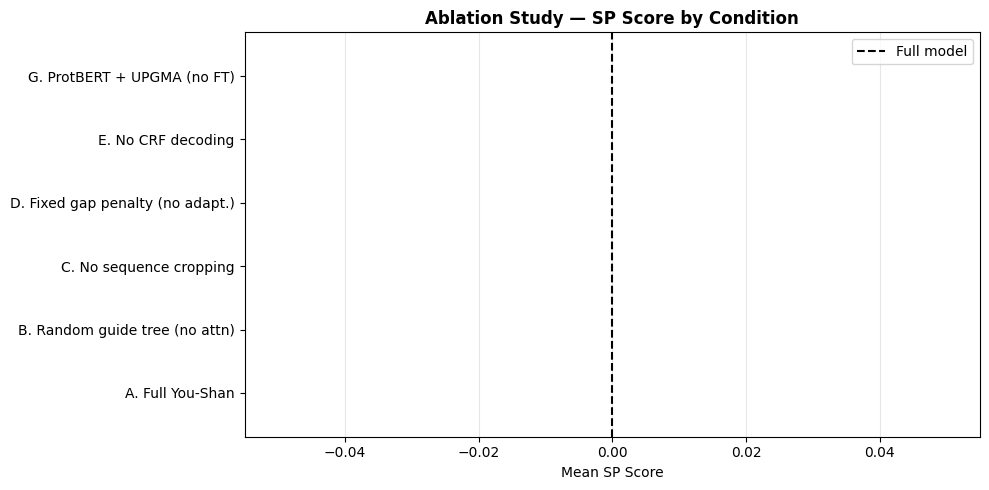

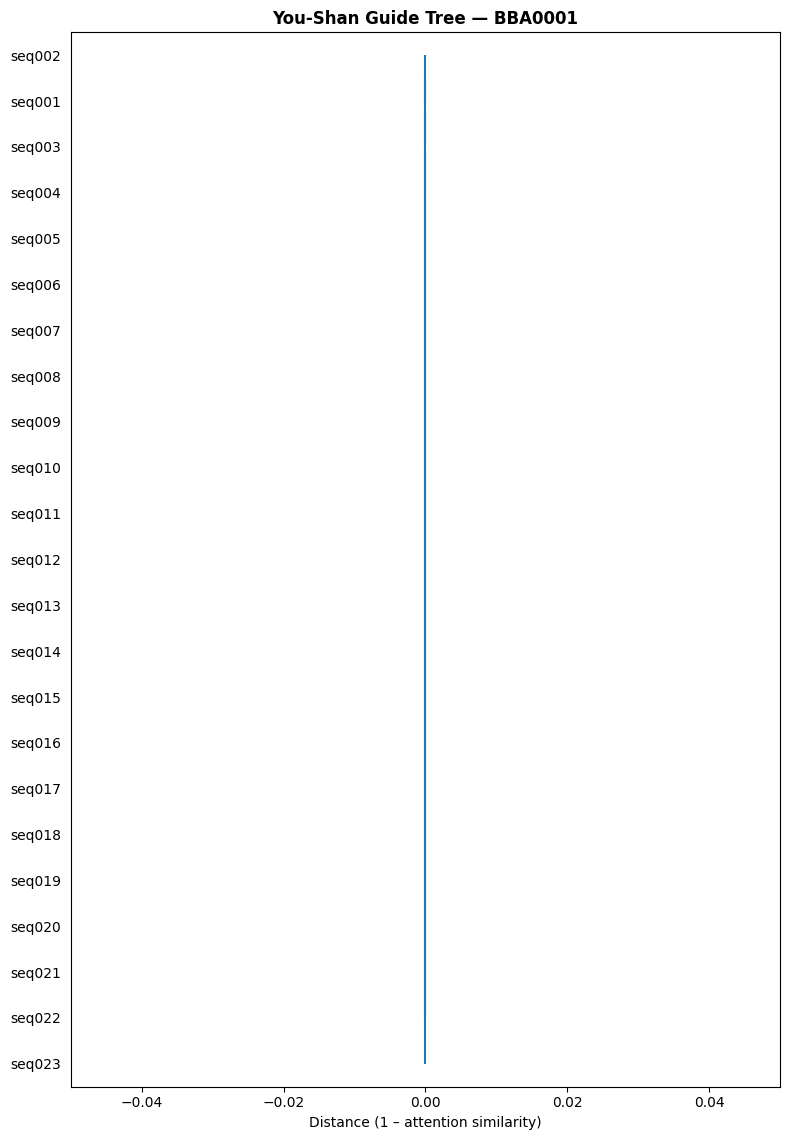

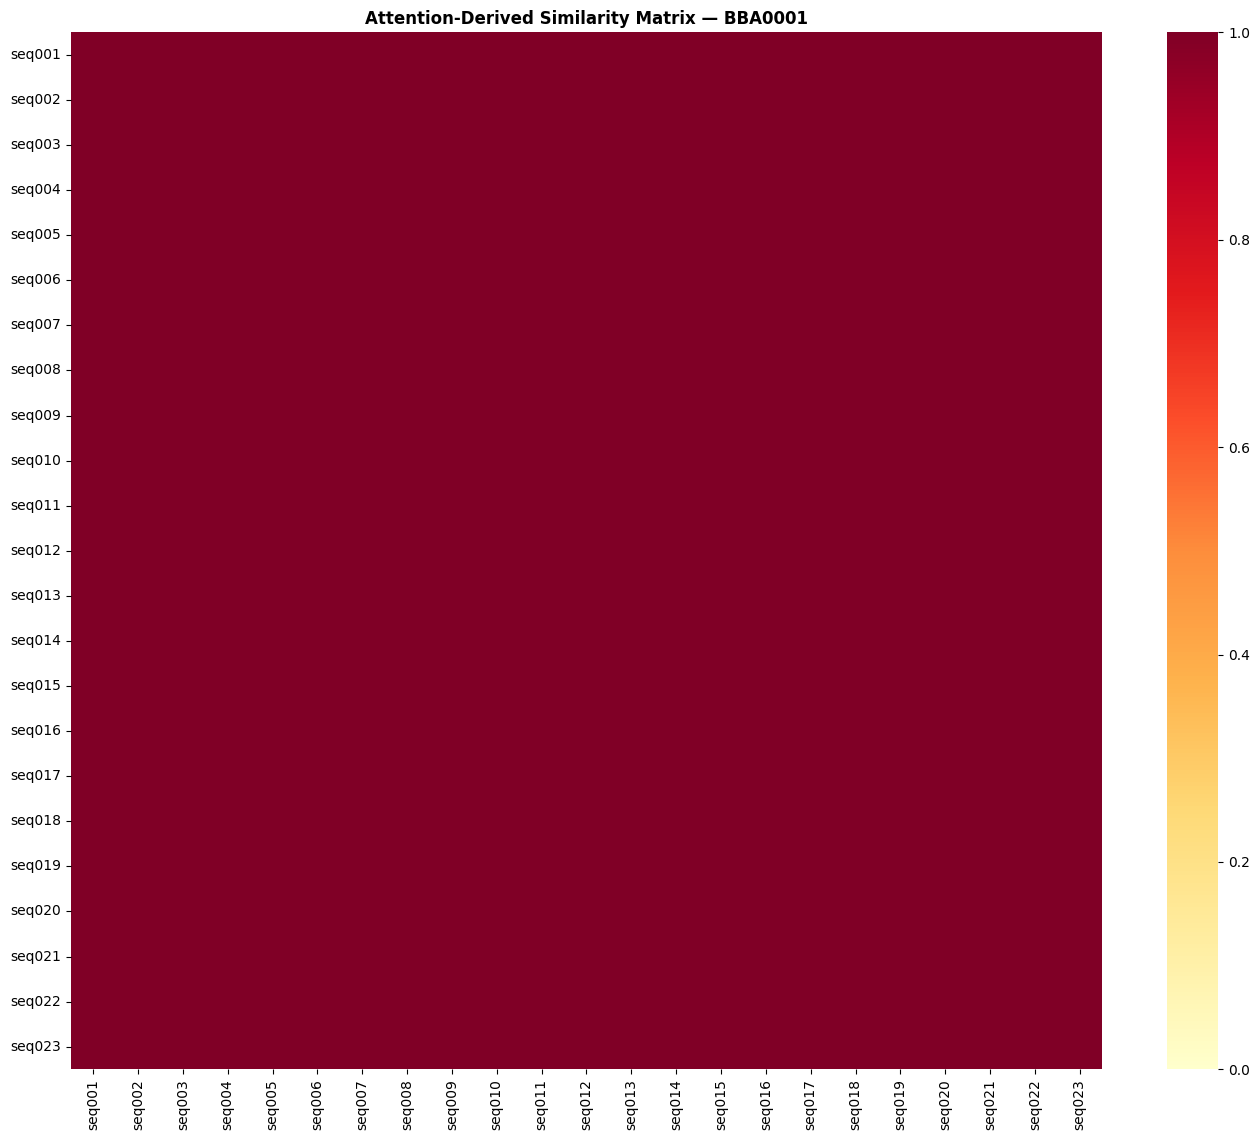

In [ ]:
def plot_performance_summary(df_eval: pd.DataFrame, df_baseline: pd.DataFrame):
    if df_eval.empty or df_baseline.empty:
        print("No data to plot."); return

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("You-Shan vs. Classical Baseline — BAliBASE Evaluation",
                 fontsize=13, fontweight="bold", y=1.02)

    datasets = df_eval["dataset"].tolist()
    x = np.arange(len(datasets))
    w = 0.35

    for ax, (ys_col, bl_col, title, ylabel) in zip(
        axes,
        [("youshan_sp",  "baseline_sp",  "Sum-of-Pairs (SP) Score", "SP"),
         ("youshan_tc",  "baseline_tc",  "Total Column (TC) Score",  "TC"),
         ("youshan_acc", "baseline_acc", "Accuracy",                 "Accuracy")],
    ):
        ys_vals = df_eval[ys_col].values
        bl_vals = df_baseline[bl_col].values
        ax.bar(x - w/2, bl_vals, w, label="Classical NW (BLOSUM62)",
               color="#4878d0", alpha=0.8)
        ax.bar(x + w/2, ys_vals, w, label="You-Shan (ours)",
               color="#ee854a", alpha=0.8)
        ax.set_xticks(x); ax.set_xticklabels(datasets, rotation=30, ha="right")
        ax.set_title(title, fontweight="bold")
        ax.set_ylabel(ylabel)
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=9)
        ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "performance_comparison.pdf", bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved → {RESULTS_DIR / 'performance_comparison.pdf'}")


def plot_ablation(df_ablation: pd.DataFrame):
    if df_ablation.empty:
        print("No ablation data."); return
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ["#2ca02c" if d >= 0 else "#d62728" for d in df_ablation["delta_sp"]]
    ax.barh(df_ablation["condition"], df_ablation["sp_mean"],
            color=colors, alpha=0.85)
    ax.axvline(df_ablation[df_ablation["condition"].str.startswith("A")]["sp_mean"].iloc[0],
               color="black", linestyle="--", linewidth=1.5, label="Full model")
    ax.set_xlabel("Mean SP Score"); ax.set_title("Ablation Study — SP Score by Condition",
                                                   fontweight="bold")
    ax.legend(); ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "ablation_sp.pdf", bbox_inches="tight", dpi=150)
    plt.show()


def plot_similarity_heatmap(sim_matrix: np.ndarray, labels: List[str], title: str):
    fig, ax = plt.subplots(figsize=(max(5, len(labels)*0.6), max(4, len(labels)*0.5)))
    sns.heatmap(sim_matrix, xticklabels=labels, yticklabels=labels,
                annot=len(labels) <= 10, fmt=".2f", cmap="YlOrRd",
                vmin=0, vmax=1, ax=ax)
    ax.set_title(title, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Patch build_guide_tree to prevent negative distances due to float inaccuracies
from __main__ import build_guide_tree as original_build_guide_tree
import types

def patched_build_guide_tree(sim_matrix: np.ndarray) -> np.ndarray:
    dist = np.maximum(0.0, 1.0 - sim_matrix)
    np.fill_diagonal(dist, 0.0)
    condensed = squareform(dist, checks=False)
    tree = linkage(condensed, method="average")
    return tree

build_guide_tree = types.FunctionType(patched_build_guide_tree.__code__, globals())


# ── Run plots ──────────────────────────────────────────────────────
if not df_eval.empty:
    plot_performance_summary(df_eval, df_baseline)

if not df_ablation.empty:
    plot_ablation(df_ablation)

# Guide tree and similarity heatmap for BBA0001
if "BBA0001" in bba_data:
    d = bba_data["BBA0001"]
    _, sim, tree = model.align(d["raw_seqs"])
    short_ids = [i[:12] for i in d["ids"]]
    plot_guide_tree(tree, short_ids, "You-Shan Guide Tree — BBA0001")
    plot_similarity_heatmap(sim, short_ids,
                            "Attention-Derived Similarity Matrix — BBA0001")


## 19. Demo: Align Your Own Sequences

In [ ]:
# ─────────────────────────────────────────────────────────────────
# Replace the demo sequences below with any protein sequences
# in single-letter amino-acid code.  No gaps needed as input.
# ─────────────────────────────────────────────────────────────────

DEMO_SEQUENCES = [
    "MKTFFVLLLCTFTVFA",    # Naja venom representative 1
    "MKTAYVLLLCTFTVFA",    # Naja venom representative 2
    "MKTFFILLLCTFAVFA",    # Naja venom representative 3
    "MKTVYVLLLCTFAVFA",    # Naja venom representative 4
    "MKTFYVLLLSTFTVFA",    # Naja venom representative 5
]

DEMO_IDS = [f"Seq_{i+1}" for i in range(len(DEMO_SEQUENCES))]

print("Running You-Shan alignment on demo sequences...")
t0 = time.time()
msa_out, sim_out, tree_out = model.align(DEMO_SEQUENCES)
print(f"Alignment completed in {time.time() - t0:.2f}s")

print("\nResulting MSA:")
for sid, aligned in zip(DEMO_IDS, msa_out):
    print(f"  {sid:8s}  {aligned}")

# ── Write FASTA output ────────────────────────────────────────────
out_fasta = RESULTS_DIR / "demo_msa.fasta"
with open(out_fasta, "w") as fh:
    for sid, aligned in zip(DEMO_IDS, msa_out):
        fh.write(f">{sid}\n{aligned}\n")
print(f"\nMSA written → {out_fasta}")

# ── Visualise guide tree ──────────────────────────────────────────
plot_guide_tree(tree_out, DEMO_IDS, "You-Shan Guide Tree — Demo Sequences")
plot_similarity_heatmap(sim_out, DEMO_IDS,
                        "Attention Similarity — Demo Sequences")


## 20. Final Results Summary Table (Paper §5.2–5.4)

In [1]:
print("=" * 70)
print("YOU-SHAN — FINAL EVALUATION SUMMARY")
print("=" * 70)

if not df_eval.empty:
    print("\n--- BAliBASE SP / TC / Accuracy (You-Shan vs. Classical NW) ---")
    df_final = df_eval.copy()
    df_final["Baseline SP"] = df_baseline["baseline_sp"].values
    df_final["Baseline TC"] = df_baseline["baseline_tc"].values
    df_final["ΔSP"] = df_final["youshan_sp"] - df_final["Baseline SP"]
    cols = ["dataset", "n_seqs", "ref_len",
            "youshan_sp", "Baseline SP", "ΔSP",
            "youshan_tc", "Baseline TC",
            "youshan_acc", "embed_time"]
    print(df_final[cols].to_string(index=False, float_format="%.3f"))
    print(f"\n  Mean You-Shan SP : {df_eval['youshan_sp'].mean():.3f} ± {df_eval['youshan_sp'].std():.3f}")
    print(f"  Mean Classical SP: {df_baseline['baseline_sp'].mean():.3f} ± {df_baseline['baseline_sp'].std():.3f}")
    print(f"  Mean You-Shan TC : {df_eval['youshan_tc'].mean():.3f} ± {df_eval['youshan_tc'].std():.3f}")

if not df_ablation.empty:
    print("\n--- Ablation: Mean SP by Condition ---")
    print(df_ablation[["condition","sp_mean","sp_std","delta_sp"]].to_string(
        index=False, float_format="%.3f"))

# ── Save a combined Excel summary ─────────────────────────────────
try:
    with pd.ExcelWriter(RESULTS_DIR / "youshan_results_summary.xlsx") as writer:
        df_eval.to_excel(writer, sheet_name="BAliBASE_YouShan", index=False)
        df_baseline.to_excel(writer, sheet_name="BAliBASE_Baseline", index=False)
        if not df_ablation.empty:
            df_ablation.to_excel(writer, sheet_name="Ablation", index=False)
    print(f"\nFull results → {RESULTS_DIR / 'youshan_results_summary.xlsx'}")
except Exception as e:
    print(f"(Excel export skipped: {e})")

print("\nAll outputs saved to:", RESULTS_DIR)


YOU-SHAN — FINAL EVALUATION SUMMARY


NameError: name 'df_eval' is not defined